<a href="https://colab.research.google.com/github/BellengerOCT/ML-Epidemiological-Cancer-Analysis-Mexico/blob/main/hospitales_pediatricos_mapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install folium geopy pandas matplotlib -q

In [2]:
import pandas as pd
import folium
from folium.plugins import LocateControl, MeasureControl, HeatMap
from geopy.distance import geodesic
from geopy.geocoders import Nominatim
import matplotlib.pyplot as plt  # <--- ESTO FALTABA
import warnings
warnings.filterwarnings('ignore')

In [3]:
h = [
{"nombre":"Hospital Infantil de México Federico Gómez","tipo":"Instituto Nacional","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Dr. Márquez 162","lat":19.4184,"lon":-99.1526,"nivel":"3er","sede":"Sí","fuente":"CLUES"},
{"nombre":"Instituto Nacional de Pediatría","tipo":"Instituto Nacional","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Insurgentes Sur 3700-C","lat":19.3012,"lon":-99.1711,"nivel":"3er","sede":"Sí","fuente":"CLUES"},
{"nombre":"Hosp. Gral. México Dr. E. Liceaga","tipo":"Hospital Federal","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Dr. Balmis 148","lat":19.4113,"lon":-99.1528,"nivel":"3er","sede":"Sí","fuente":"CIFRHS"},
{"nombre":"HRAE Ixtapaluca","tipo":"Alta Especialidad","sector":"Público","estado":"Edo.Méx.","ciudad":"Ixtapaluca","dir":"Carr. Méx-Puebla Km34.5","lat":19.3189,"lon":-98.8861,"nivel":"3er","sede":"Sí","fuente":"HRAE"},
{"nombre":"HRAE Tapachula Ped.","tipo":"Alta Especialidad","sector":"Público","estado":"Chiapas","ciudad":"Tapachula","dir":"Ciudad Salud","lat":14.889,"lon":-92.2668,"nivel":"3er","sede":"Sí","fuente":"HRAE"},
{"nombre":"HRAE Veracruz","tipo":"Alta Especialidad","sector":"Público","estado":"Veracruz","ciudad":"Veracruz","dir":"20 de Noviembre 1074","lat":19.1738,"lon":-96.1342,"nivel":"3er","sede":"Sí","fuente":"HRAE"},
{"nombre":"HRAE Bicentenario Cd. Victoria","tipo":"Alta Especialidad","sector":"Público","estado":"Tamaulipas","ciudad":"Cd.Victoria","dir":"Lib. Naciones Unidas 6501","lat":23.7175,"lon":-99.1707,"nivel":"3er","sede":"Sí","fuente":"HRAE"},
{"nombre":"HRAE Península Yucatán","tipo":"Alta Especialidad","sector":"Público","estado":"Yucatán","ciudad":"Mérida","dir":"Calle 7 No.433 Altabrisa","lat":21.019,"lon":-89.596,"nivel":"3er","sede":"Sí","fuente":"HRAE"},
{"nombre":"UMAE Ped. CMN Siglo XXI","tipo":"IMSS-UMAE","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Cuauhtémoc 330","lat":19.417,"lon":-99.1537,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"UMAE Gral. La Raza Div.Ped.Qx","tipo":"IMSS-UMAE","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Calz.Vallejo y Jacarandas","lat":19.4695,"lon":-99.1529,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"UMAE Ped. CMN Occidente","tipo":"IMSS-UMAE","sector":"Público","estado":"Jalisco","ciudad":"Guadalajara","dir":"B.Domínguez 735","lat":20.672,"lon":-103.338,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"UMAE Esp.25 CMN Noreste","tipo":"IMSS-UMAE","sector":"Público","estado":"N.León","ciudad":"Monterrey","dir":"Lincoln y F.Velázquez","lat":25.75,"lon":-100.315,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"UMAE GinecoPed.48 León","tipo":"IMSS-UMAE","sector":"Público","estado":"Guanajuato","ciudad":"León","dir":"López Mateos esq Insurgentes","lat":21.12,"lon":-101.659,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"UMAE Esp. CMN Puebla","tipo":"IMSS-UMAE","sector":"Público","estado":"Puebla","ciudad":"Puebla","dir":"2 Poniente 1101","lat":19.037,"lon":-98.208,"nivel":"3er","sede":"Sí","fuente":"IMSS"},
{"nombre":"CMN 20 Nov ISSSTE","tipo":"ISSSTE","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Félix Cuevas 540","lat":19.374,"lon":-99.169,"nivel":"3er","sede":"Sí","fuente":"ISSSTE"},
{"nombre":"Hosp.Reg. López Mateos ISSSTE","tipo":"ISSSTE","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Universidad 1321","lat":19.356,"lon":-99.177,"nivel":"3er","sede":"Sí","fuente":"ISSSTE"},
{"nombre":"Ped. Moctezuma SEDESA","tipo":"SS Estatal","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Oriente 158 No.189","lat":19.437,"lon":-99.102,"nivel":"2do","sede":"Sí","fuente":"SEDESA"},
{"nombre":"Ped. Iztacalco SEDESA","tipo":"SS Estatal","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Terraplén Río Frío s/n","lat":19.388,"lon":-99.095,"nivel":"2do","sede":"Sí","fuente":"SEDESA"},
{"nombre":"Ped. La Villa SEDESA","tipo":"SS Estatal","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Insurgentes Nte y Misterios","lat":19.483,"lon":-99.121,"nivel":"2do","sede":"No","fuente":"SEDESA"},
{"nombre":"Ped. Iztapalapa SEDESA","tipo":"SS Estatal","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Ermita Iztapalapa s/n","lat":19.355,"lon":-99.056,"nivel":"2do","sede":"No","fuente":"SEDESA"},
{"nombre":"Civil GDL Dr. J.I. Menchaca","tipo":"Hospital Civil","sector":"Público","estado":"Jalisco","ciudad":"Guadalajara","dir":"S. Quevedo y Zubieta 750","lat":20.659,"lon":-103.35,"nivel":"3er","sede":"Sí","fuente":"UdeG"},
{"nombre":"Civil GDL Fray A. Alcalde","tipo":"Hospital Civil","sector":"Público","estado":"Jalisco","ciudad":"Guadalajara","dir":"Hospital 278 El Retiro","lat":20.678,"lon":-103.352,"nivel":"3er","sede":"Sí","fuente":"UdeG"},
{"nombre":"Hosp. Niño IMIEM Toluca","tipo":"SS Estatal","sector":"Público","estado":"Edo.Méx.","ciudad":"Toluca","dir":"Solidaridad Las Torres 101","lat":19.293,"lon":-99.636,"nivel":"3er","sede":"Sí","fuente":"IMIEM"},
{"nombre":"Hosp. Niño Morelense","tipo":"SS Estatal","sector":"Público","estado":"Morelos","ciudad":"Cuernavaca","dir":"G.Gómez Azcárate 205","lat":18.938,"lon":-99.251,"nivel":"3er","sede":"Sí","fuente":"SSM"},
{"nombre":"Hosp. Niño Poblano","tipo":"SS Estatal","sector":"Público","estado":"Puebla","ciudad":"Puebla","dir":"19 Poniente 1301","lat":19.043,"lon":-98.216,"nivel":"3er","sede":"Sí","fuente":"SS Puebla"},
{"nombre":"Hosp. Niño y Mujer Oaxaqueña","tipo":"SS Estatal","sector":"Público","estado":"Oaxaca","ciudad":"Oaxaca","dir":"Símbolos Patrios 1003","lat":17.061,"lon":-96.693,"nivel":"3er","sede":"Sí","fuente":"SSO"},
{"nombre":"Hosp. Central Morones Prieto","tipo":"SS Estatal","sector":"Público","estado":"SLP","ciudad":"SLP","dir":"V. Carranza 2395","lat":22.143,"lon":-100.955,"nivel":"3er","sede":"Sí","fuente":"CIFRHS"},
{"nombre":"Ped. Sinaloa Dr. R. Aguilar","tipo":"SS Estatal","sector":"Público","estado":"Sinaloa","ciudad":"Culiacán","dir":"Blvd. Constitución s/n","lat":24.805,"lon":-107.394,"nivel":"3er","sede":"Sí","fuente":"SSS"},
{"nombre":"Infantil Edo. Sonora","tipo":"SS Estatal","sector":"Público","estado":"Sonora","ciudad":"Hermosillo","dir":"Reforma 355 Norte","lat":29.1,"lon":-110.97,"nivel":"3er","sede":"Sí","fuente":"SSS"},
{"nombre":"Infantil Chihuahua","tipo":"SS Estatal","sector":"Público","estado":"Chihuahua","ciudad":"Chihuahua","dir":"Av. Pacheco y Progreso","lat":28.627,"lon":-106.093,"nivel":"2do","sede":"No","fuente":"SESA Chih."},
{"nombre":"Infantil Morelia Eva Sámano","tipo":"SS Estatal","sector":"Público","estado":"Michoacán","ciudad":"Morelia","dir":"Bosque Cuauhtémoc s/n","lat":19.702,"lon":-101.184,"nivel":"2do","sede":"No","fuente":"SSM"},
{"nombre":"Niño DIF Pachuca","tipo":"DIF","sector":"Público","estado":"Hidalgo","ciudad":"Pachuca","dir":"Ferrocarril Central s/n","lat":20.115,"lon":-98.756,"nivel":"2do","sede":"No","fuente":"DIF Hgo."},
{"nombre":"Niño F.Gómez Santos Saltillo","tipo":"SS Estatal","sector":"Público","estado":"Coahuila","ciudad":"Saltillo","dir":"Colosio y Periférico","lat":25.388,"lon":-100.97,"nivel":"2do","sede":"No","fuente":"SESA Coah."},
{"nombre":"Niño y Adolescente Querétaro","tipo":"SS Estatal","sector":"Público","estado":"Querétaro","ciudad":"Querétaro","dir":"Av. de la Luz s/n","lat":20.569,"lon":-100.402,"nivel":"2do","sede":"No","fuente":"SESEQ"},
{"nombre":"Infantil Tlaxcala","tipo":"SS Estatal","sector":"Público","estado":"Tlaxcala","ciudad":"Tlaxcala","dir":"Carr. S.M.Texmelucan Km2.5","lat":19.31,"lon":-98.24,"nivel":"2do","sede":"No","fuente":"SESA Tlax."},
{"nombre":"Hosp. Universitario UANL","tipo":"Universitario","sector":"Público","estado":"N.León","ciudad":"Monterrey","dir":"Madero y Gonzalitos","lat":25.688,"lon":-100.345,"nivel":"3er","sede":"Sí","fuente":"UANL"},
{"nombre":"Hospital Central Militar","tipo":"SEDENA","sector":"Público","estado":"CDMX","ciudad":"CDMX","dir":"Ávila Camacho s/n","lat":19.457,"lon":-99.219,"nivel":"3er","sede":"Sí","fuente":"SEDENA"},
{"nombre":"ABC Observatorio","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"Sur 136 No. 116","lat":19.393,"lon":-99.198,"nivel":"3er","sede":"Sí","fuente":"ABC"},
{"nombre":"ABC Santa Fe","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"C. Graef Fernández 154","lat":19.369,"lon":-99.262,"nivel":"3er","sede":"Sí","fuente":"ABC"},
{"nombre":"Médica Sur","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"Puente de Piedra 150","lat":19.311,"lon":-99.164,"nivel":"3er","sede":"Sí","fuente":"M.Sur"},
{"nombre":"Hospital Español","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"Ejército Nacional 613","lat":19.437,"lon":-99.186,"nivel":"3er","sede":"Sí","fuente":"H.Español"},
{"nombre":"Ángeles Pedregal","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"Sta. Teresa 1055","lat":19.31,"lon":-99.221,"nivel":"3er","sede":"No","fuente":"H.Ángeles"},
{"nombre":"Star Médica Infantil","tipo":"Privado","sector":"Privado","estado":"CDMX","ciudad":"CDMX","dir":"Cerro del Vigía 7","lat":19.349,"lon":-99.171,"nivel":"2do","sede":"No","fuente":"StarMédica"},
{"nombre":"San José TecSalud","tipo":"Privado","sector":"Privado","estado":"N.León","ciudad":"Monterrey","dir":"Morones Prieto 3000","lat":25.653,"lon":-100.286,"nivel":"3er","sede":"Sí","fuente":"TecSalud"},
{"nombre":"Zambrano Hellion TecSalud","tipo":"Privado","sector":"Privado","estado":"N.León","ciudad":"S.P.G.García","dir":"San Patricio 112","lat":25.652,"lon":-100.348,"nivel":"3er","sede":"Sí","fuente":"TecSalud"},
]
df = pd.DataFrame(h)
print(f'Base: {len(df)} hospitales | Pub:{len(df[df.sector=="Público"])} Priv:{len(df[df.sector=="Privado"])} | Sedes:{len(df[df.sede=="Sí"])} | Entidades:{df.estado.nunique()}/32')

Base: 45 hospitales | Pub:37 Priv:8 | Sedes:35 | Entidades:21/32


In [4]:
mapa = folium.Map(location=[23.6345,-102.5528], zoom_start=5, tiles='CartoDB positron', control_scale=True)
gp = folium.FeatureGroup(name='Sector Público',show=True)
gv = folium.FeatureGroup(name='Sector Privado',show=True)
for _,r in df.iterrows():
    pp = f"<div style='font-family:Arial;width:260px;'><b>{r['nombre']}</b><br>Tipo: {r['tipo']}<br>Sector: {r['sector']}<br>Estado: {r['estado']}<br>Dir: {r['dir']}<br>Nivel: {r['nivel']}<br>Sede formación: {r['sede']}</div>"
    c='green' if r['sector']=='Público' else 'orange'
    m=folium.Marker([r['lat'],r['lon']],popup=folium.Popup(pp,max_width=300),tooltip=r['nombre'],icon=folium.Icon(color=c,icon='plus-sign',prefix='glyphicon'))
    if r['sector']=='Público': m.add_to(gp)
    else: m.add_to(gv)
gp.add_to(mapa); gv.add_to(mapa)
folium.LayerControl(collapsed=False).add_to(mapa)
LocateControl(strings={'title':'Mi ubicación'}).add_to(mapa)
MeasureControl(primary_length_unit='kilometers').add_to(mapa)
mapa

In [5]:
def hospital_cercano(ubi, df, top=5):
    if isinstance(ubi, str):
        # Aumentamos el timeout para asegurar respuesta
        loc = Nominatim(user_agent='cirugia_pediatrica_mx', timeout=10).geocode(f'{ubi}, México')
        if not loc:
            print('Ubicación no encontrada. Intenta con el nombre de la ciudad y estado.')
            return None,None
        co=(loc.latitude,loc.longitude)
        print(f'Ubicación detectada: {loc.address}')
    else: co=ubi

    d=df.copy()
    # Calculamos distancia
    d['km']=d.apply(lambda r:round(geodesic(co,(r.lat,r.lon)).km,1),axis=1)
    d=d.sort_values('km').head(top).reset_index(drop=True)

    print(f"\n--- Los {top} hospitales más cercanos ---")
    for i,r in d.iterrows():
        print(f"{i+1}. {r['nombre']} - {r['km']}km ({r['tipo']}, {r['estado']})")

    mr=folium.Map(location=co,zoom_start=8,tiles='CartoDB positron')
    folium.Marker(co,tooltip='Tu ubicación',icon=folium.Icon(color='red',icon='user',prefix='glyphicon')).add_to(mr)

    for i,r in d.iterrows():
        folium.Marker([r.lat,r.lon],tooltip=f"{i+1}. {r['nombre']} ({r['km']}km)",icon=folium.Icon(color='green' if i==0 else 'blue',icon='plus-sign',prefix='glyphicon')).add_to(mr)
        if i==0:
            folium.PolyLine([co,[r.lat,r.lon]],weight=3,color='red',dash_array='10', tooltip=f"Distancia: {r['km']} km").add_to(mr)

    return d,mr

In [6]:
res, mc = hospital_cercano("Aguascalientes", df)
mc

Ubicación detectada: Aguascalientes, Municipio de Aguascalientes, Aguascalientes, 20000, México

--- Los 5 hospitales más cercanos ---
1. UMAE GinecoPed.48 León - 107.0km (IMSS-UMAE, Guanajuato)
2. Hosp. Central Morones Prieto - 141.6km (SS Estatal, SLP)
3. UMAE Ped. CMN Occidente - 172.0km (IMSS-UMAE, Jalisco)
4. Civil GDL Fray A. Alcalde - 172.4km (Hospital Civil, Jalisco)
5. Civil GDL Dr. J.I. Menchaca - 173.9km (Hospital Civil, Jalisco)


In [7]:
# ciudad = input("Escribe tu ciudad para buscar el hospital más cercano: ")
# if ciudad:
#     res, mc = hospital_cercano(ciudad, df)
#     mc

In [8]:
mh = folium.Map(location=[23.6,-102.5],zoom_start=5,tiles='CartoDB dark_matter')
HeatMap([[r.lat,r.lon] for _,r in df.iterrows()],radius=30,blur=20, max_zoom=1).add_to(mh)
mh

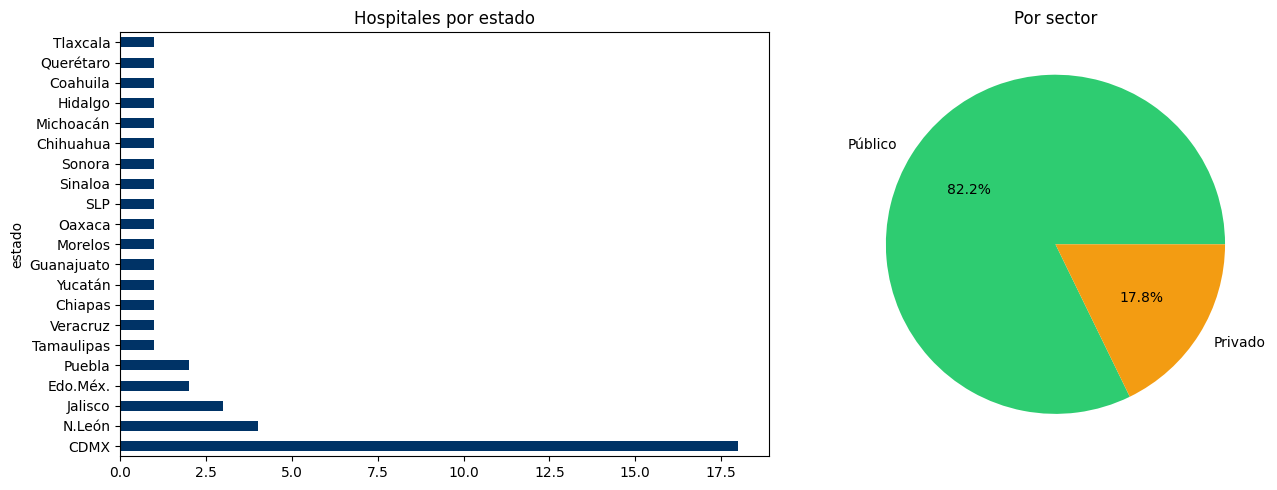

In [9]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
df['estado'].value_counts().plot(kind='barh',ax=ax[0],color='#003366')
ax[0].set_title('Hospitales por estado')
df['sector'].value_counts().plot(kind='pie',ax=ax[1],colors=['#2ecc71','#f39c12'],autopct='%1.1f%%')
ax[1].set_title('Por sector'); ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [10]:
df.to_csv('hospitales_cirugia_pediatrica.csv',index=False,encoding='utf-8-sig')
mapa.save('mapa_principal.html')
mh.save('mapa_calor.html')
print('Exportado exitosamente: CSV + 2 HTML')

Exportado exitosamente: CSV + 2 HTML
